# SEEDS - 3 - Potential Future CGSs Sites Search

This notebook combines and formalizes data to identify potential future Community Growing Schemes (CGSs) sites in **Leeds**. 

The workflow is designed to be adaptable for any UK local authority, which is selected at the beginning of the notebook. However, as this project focuses on Leeds, several datasets are sourced from the Leeds City Council and other Leeds-based organisations, making parts of the analysis project-specific.

Where possible, the notebook automatically retrieves the most up-to-date available data. Some datasets are however static and have not been updated for several years, these must thus be dowloaded manually.

In [1]:
pip install matplotlib mapclassify geopandas numpy scipy folium plotly fiona osmnx hashlib sklearn

Note: you may need to restart the kernel to use updated packages.


ERROR: Ignored the following yanked versions: 20081119
ERROR: Could not find a version that satisfies the requirement hashlib (from versions: none)
ERROR: No matching distribution found for hashlib

[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
#Import packages
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
import os
import fiona
import hashlib
import folium
import mapclassify

In [3]:
#Choose Local Authority to work with
LOCAL_AUTHORITY_NAME = 'Leeds' 

output_file = f'output_{LOCAL_AUTHORITY_NAME}.gpkg'

In [4]:
#Save paths of local computer and workspace in VS Code
#This allows to save processed datasets later on
DATA_DIR= r"C:\Users\qxnq723\Desktop\Project_2\Datasets"
workspace_path= r"C:\Users\qxnq723\Desktop\Project_2\Dashboard Development"

## 1- Define Local Authority Boundaries

The UK local authorities boundaries data was downloaded from [geoportal](https://geoportal.statistics.gov.uk/datasets/ons::local-authority-districts-may-2024-boundaries-uk-bfe-2/explore?location=53.495068%2C-0.354857%2C7).
The UK data is subsetted to only include the boundaries of the local authority chosen at the start, in the case of this study Leeds is chosen.

In [5]:
# UK local authorities file path
UK_LAD_PATH = "../Data/Raw_Data/Local_Authority_Districts_May_2024_Boundaries_UK_BFE_6583563793708892075/LAD_MAY_2024_UK_BFE.shp"

print(f"Configured for: {LOCAL_AUTHORITY_NAME}")
print(f"Data directory: {DATA_DIR}")

Configured for: Leeds
Data directory: C:\Users\qxnq723\Desktop\Project_2\Datasets


In [6]:
# Load UK Local Authority District boundaries
print("Loading UK Local Authority District boundaries...")
LAD_2024 = gpd.read_file(UK_LAD_PATH)

print(f"Loaded {len(LAD_2024)} local authority districts")
print(f"Available LADs include: {sorted(LAD_2024['LAD24NM'].unique())[:10]}...")

# Check if our chosen LAD exists 
if LOCAL_AUTHORITY_NAME in LAD_2024['LAD24NM'].values:
    print(f"Found {LOCAL_AUTHORITY_NAME} in the dataset")
    target_lad = LAD_2024[LAD_2024['LAD24NM'] == LOCAL_AUTHORITY_NAME]
    print(f"Area: {target_lad.to_crs('EPSG:27700').geometry.area.iloc[0]/1000000:.2f} km²")
else:
    print(f"{LOCAL_AUTHORITY_NAME} not found in dataset")
    print("Available LADs:", sorted(LAD_2024['LAD24NM'].unique()))

Loading UK Local Authority District boundaries...
Loaded 361 local authority districts
Available LADs include: ['Aberdeen City', 'Aberdeenshire', 'Adur', 'Amber Valley', 'Angus', 'Antrim and Newtownabbey', 'Ards and North Down', 'Argyll and Bute', 'Armagh City, Banbridge and Craigavon', 'Arun']...
Found Leeds in the dataset
Area: 551.70 km²


Isolate the outline of the chosen Local Authority (in this case Leeds), to clip other datasets to it.

<Axes: >

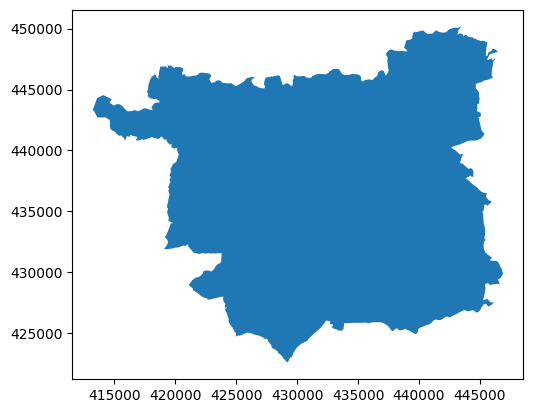

In [7]:
#Keep only chosen LA and plot it
chosen_LA = LAD_2024[LAD_2024['LAD24NM'] == LOCAL_AUTHORITY_NAME]
chosen_LA.plot()

In [8]:
#Check CRS
print(chosen_LA.crs)

EPSG:27700


In [9]:
#Create outline of chosen LA
chosen_LA['outline'] = 1
LA_outline = chosen_LA.dissolve(by= 'outline')

A function is created to subset datasets to the chosen local authority boundaries.

In [10]:
#Create function to subset data to the chosen LA
def subset_to_LAD(LAD_gdf, LAD_column_name, LAD_name, data_to_subset):
    """
    Subset a greenspace (or similar file) to only include greenspaces 
    within a chosen local authority.
    
    Parameters
    ----------
    LAD_gdf : geopandas.GeoDataFrame
        GeoDataFrame containing local authority district boundaries
    LAD_column_name : str
        Name of the column containing LAD names
    LAD_name : str
        Name of the specific LAD to subset to
    data_to_subset : geopandas.GeoDataFrame
        Data to be subset to the chosen LAD
        
    Returns
    -------
    geopandas.GeoDataFrame
        Data subset to only include features within the chosen LAD
    """
    chosen_LAD = LAD_gdf.loc[LAD_gdf[LAD_column_name] == LAD_name, :]
    chosen_LAD = chosen_LAD.to_crs(data_to_subset.crs)
    data_subset_to_LAD = data_to_subset[data_to_subset.within(chosen_LAD.union_all())]
    return data_subset_to_LAD

**The rest of the notebook collects and cleans different datasets to create individual files for each layer that will be added to the 'Imagining Future Growing Spaces' page of the SEEDS dashboard.**

## 2- Creating the Brownfields layer - Leeds City Council

### A- Web Scraping

The polygons of brownfields in Leeds are scraped from the Leeds City Council ArcGis webpage.

In [11]:
import requests
from shapely.geometry import Polygon, MultiPolygon

url= "https://mapservices.leeds.gov.uk/arcgis/rest/services/Public/Strategic_Planning/MapServer/14/query"

headers= {
    'User-Agent': 'Mozilla/5.0',
    'Referer': 'https://www.argis.com'
}

#List to store feature rows
all_rows= []
#Control pagination
offset= 0
batch_size= 2000

#Loop through all data
while True:
    params = {
    'where': '1=1', #get everything
    'outFields': '*', #retrun all columns
    'returnGeometry': 'true', #include spatial data (polygons)
    'f': 'json', #response format
    'resultOffset': offset,
    'resultRecordCount': batch_size
    }

    #Send request
    data = requests.get(url, params= params, headers= headers).json()

    #Get list of features
    features = data.get('features', [])
    if not features:
        break
    
    #Loop through features
    for f in features:
        row= f['attributes']
        geom = f.get('geometry')
    
        #Convert ArcGis data to Python geoemtries
        if geom and 'rings' in geom:
            try:
                row['geometry'] = Polygon(geom['rings'][0])
            except Exception:
                row['geometry'] = None
        #Store results
        all_rows.append(row)

    offset += batch_size #move to next batch
    print(f'Fetched {offset} records')

#Convert to GeoDataFrame
LCC_brownfields = pd.DataFrame(all_rows)
LCC_brownfields = gpd.GeoDataFrame(LCC_brownfields, geometry='geometry', crs='EPSG:27700')

print('Done:', len(LCC_brownfields), 'brownfields in Leeds')

Fetched 2000 records
Fetched 4000 records
Done: 2602 brownfields in Leeds


In [12]:
#Check
LCC_brownfields.info()
print(LCC_brownfields.crs)

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 2602 entries, 0 to 2601
Data columns (total 42 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   OBJECTID_1        2602 non-null   int64   
 1   OBJECTID          1998 non-null   float64 
 2   BOUNDNUM          2602 non-null   str     
 3   YEAR              2602 non-null   float64 
 4   ORGANISATI        2602 non-null   str     
 5   ORGANISA_1        2602 non-null   str     
 6   SITEREFERE        2602 non-null   str     
 7   PREVIOUSLY        2602 non-null   str     
 8   SITENAMEAD        2602 non-null   str     
 9   SITEPLANUR        2602 non-null   str     
 10  COORDINATE        2602 non-null   str     
 11  GEOX              2602 non-null   float64 
 12  GEOY              2602 non-null   float64 
 13  HECTARES          2602 non-null   float64 
 14  OWNERSHIPS        2602 non-null   str     
 15  DELIVERABL        2602 non-null   str     
 16  PLANNINGST      

In [13]:
LCC_brownfields['OWNERSHIPS'].value_counts()

OWNERSHIPS
not owned by a public authority    1727
owned by a public authority         402
Unknown                             265
mixed ownership                     131
Public ownership                     77
Name: count, dtype: int64

In [14]:
#Only the publicly owned brownfields are kept
keep = ['owned by a public authority', 'mixed ownership', 'Public ownership']
LCC_brownfields = LCC_brownfields[LCC_brownfields['OWNERSHIPS'].isin(keep)]

In [15]:
LCC_brownfields.head()

,OBJECTID_1,OBJECTID,BOUNDNUM,YEAR,ORGANISATI,ORGANISA_1,SITEREFERE,PREVIOUSLY,SITENAMEAD,SITEPLANUR,...,SITEREFE_1,EASTING,NORTHING,SORT,BOUNDREF,SE_ANNO_CAD_DATA,GLOBALID,SHAPE.AREA,SHAPE.LEN,geometry
3,4,125.0,SHL002281,2016.0,http://opendatacommunities.org/id/metropolitan...,Leeds City Council,SHL00228,,"""Ardsley Sidings East Ardsley""",,...,494,430853.0,426235.0,20160494.0,SHL002281,None,{69F3C83D-915C-4544-9D0B-AC4D24C1BA8A},0,0,"POLYGON ((430741.567 426377.647, 430744.212 42..."
8,9,367.0,SHL001711,2016.0,http://opendatacommunities.org/id/metropolitan...,Leeds City Council,SHL00171,,"""Cropper Gate LS1""",,...,402,429170.0,433556.0,20160402.0,SHL001711,None,{4F9A3F9C-8F26-44CE-993F-FEBF3FBF3ABA},0,0,"POLYGON ((429177.475 433531.556, 429174.756 43..."
16,17,616.0,SHL000732,2016.0,http://opendatacommunities.org/id/metropolitan...,Leeds City Council,SHL00073,,"""Lowfold, East Street, Leeds, LS9 8""",,...,207,431359.0,432622.0,20160207.0,SHL000732,None,{C86D8B29-A8A9-42FF-B39C-4595D117B2A8},0,0,"POLYGON ((431245.66 432738.84, 431247.43 43274..."
20,21,712.0,SHL001631,2016.0,http://opendatacommunities.org/id/metropolitan...,Leeds City Council,SHL00163,,"""Beckhill Garth/Approach""",,...,383,429149.0,436892.0,20160383.0,SHL001631,None,{85BE61C7-5DB0-4FE6-B552-250C958F4AA1},0,0,"POLYGON ((429041.409 436841.334, 429041.6 4368..."
22,23,807.0,SHL003591,2016.0,http://opendatacommunities.org/id/metropolitan...,Leeds City Council,SHL00359,,"""South Parkway/york Road Depot LS14""",,...,816,435801.0,435699.0,20160816.0,SHL003591,None,{BD013A30-EC38-4450-90D9-9FAD4F8B15AF},0,0,"POLYGON ((435736.191 435714.073, 435736.507 43..."


In [16]:
print(LCC_brownfields.is_valid.value_counts())
#Fix any invalid geometries
LCC_brownfields['geometry'] = LCC_brownfields.buffer(0)
print(LCC_brownfields.is_valid.value_counts())

True     605
False      5
Name: count, dtype: int64


True    610
Name: count, dtype: int64


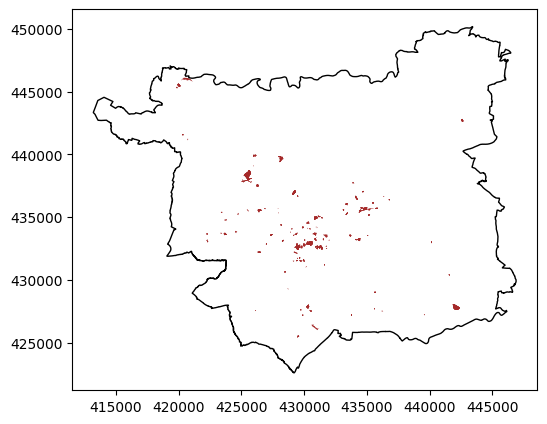

In [17]:
fig , ax = plt.subplots(figsize=(6, 6))

#Plot outline first
LA_outline.plot(
    ax= ax,
    facecolor= 'none',
    edgecolor='black',
    linewidth=1
)

#Plot brown fields
LCC_brownfields.plot(
    ax=ax,
    color='brown'
)

plt.show()

In [18]:
#Convert CRS to 4326 for mapping on dashboard
print(LCC_brownfields.crs)
LCC_brownfields = LCC_brownfields.to_crs(4326)
print(LCC_brownfields.crs)

EPSG:27700
EPSG:4326


In [19]:
LCC_brownfields.loc[LCC_brownfields['SITENAMEAD'].duplicated(keep=False), ["SITENAMEAD", "YEAR"]].sort_values("SITENAMEAD")

,SITENAMEAD,YEAR
1485,"""1 Union Court, \rWestgate\r, Otley\r""",2020.0
1837,"""1 Union Court, \rWestgate\r, Otley\r""",2021.0
1167,"""1 Union Court, \rWestgate\r, Otley\r""",2019.0
2193,"""1 Union Court, \rWestgate\r, Otley\r""",2022.0
2428,"""1 Union Court, \rWestgate\r, Otley\r""",2023.0
...,...,...
538,"""York road/ South Parkway, Seacroft""",2017.0
2228,"""York road/ South Parkway, Seacroft""",2022.0
886,"""York road/ South Parkway, Seacroft""",2018.0
1540,"""York road/ South Parkway, Seacroft""",2020.0


In [20]:
#There are duplicates with values for several years
#so only the latest year is kept

LCC_brownfields= (
    LCC_brownfields
    .sort_values("YEAR", ascending=False)
    .drop_duplicates(subset="SITENAMEAD", keep="first")
    .reset_index(drop=True)
)

LCC_brownfields.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 42 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   OBJECTID_1        121 non-null    int64   
 1   OBJECTID          50 non-null     float64 
 2   BOUNDNUM          121 non-null    str     
 3   YEAR              121 non-null    float64 
 4   ORGANISATI        121 non-null    str     
 5   ORGANISA_1        121 non-null    str     
 6   SITEREFERE        121 non-null    str     
 7   PREVIOUSLY        121 non-null    str     
 8   SITENAMEAD        121 non-null    str     
 9   SITEPLANUR        121 non-null    str     
 10  COORDINATE        121 non-null    str     
 11  GEOX              121 non-null    float64 
 12  GEOY              121 non-null    float64 
 13  HECTARES          121 non-null    float64 
 14  OWNERSHIPS        121 non-null    str     
 15  DELIVERABL        121 non-null    str     
 16  PLANNINGST        

In [21]:
#Check no more duplicates
LCC_brownfields.loc[LCC_brownfields['SITENAMEAD'].duplicated(keep=False), ["SITENAMEAD", "YEAR"]].sort_values("SITENAMEAD")

,SITENAMEAD,YEAR


In [22]:
LCC_brownfields["DEVELOPMEN"].unique()

<StringArray>
[                                                              'Variation of condition 2 (approved plans) of approval 15/00415/FU to amend the approved drawings to reflect layout and design changes including an increase in units to 316 from 312 dwellings\r',
                                                                                                                                                                                                                                                              ' ',
                                                              'Co-housing scheme comprising 28 dwellings, 1 x 5-bedroom HMO, and common house; 30 apartments for over 55s; and four self-build plots (63 units in total), with associated access and landscaping',
  'Outline application (all matters reserved except for access) for a phased mixed use development comprising demolition of existing buildings, up to 850 residential units (C3), business uses (B1), flexible co

In [23]:
LCC_brownfields.head()

,OBJECTID_1,OBJECTID,BOUNDNUM,YEAR,ORGANISATI,ORGANISA_1,SITEREFERE,PREVIOUSLY,SITENAMEAD,SITEPLANUR,...,SITEREFE_1,EASTING,NORTHING,SORT,BOUNDREF,SE_ANNO_CAD_DATA,GLOBALID,SHAPE.AREA,SHAPE.LEN,geometry
0,4509,NaN,SHL000732,2023.0,http://opendatacommunities.org/id/metropolitan...,Leeds City Council,SHL00073,,"""Lowfold, East Street, Leeds, LS9 8""",https://leedscc.maps.arcgis.com/apps/webappvie...,...,207,431361.0,432629.0,NaN,SHL000732,None,{AE179FB4-039E-4984-9353-28AC3B3EC63F},0,0,"POLYGON ((-1.5272 53.79003, -1.52718 53.79005,..."
1,4588,NaN,SHL014041,2023.0,http://opendatacommunities.org/id/metropolitan...,Leeds City Council,SHL01404,,"""Amberton Hop, Thorn Mount, Gipton""",https://leedscc.maps.arcgis.com/apps/webappvie...,...,5017,433133.0,435576.0,NaN,SHL014041,None,{8E8278D2-CF26-4907-BBA8-8321F954318D},0,0,"POLYGON ((-1.4988 53.81577, -1.49875 53.81577,..."
2,4505,NaN,SHL001132,2023.0,http://opendatacommunities.org/id/metropolitan...,Leeds City Council,SHL00113,,"""Former Site Of 79 Roundhay Road""",https://leedscc.maps.arcgis.com/apps/webappvie...,...,264,431188.0,435060.0,NaN,SHL001132,None,{49241AA1-E6C8-4DD2-A4DB-4BEE26638077},0,0,"POLYGON ((-1.52567 53.81102, -1.52569 53.81096..."
3,4503,NaN,SHL007592,2023.0,http://opendatacommunities.org/id/metropolitan...,Leeds City Council,SHL00759,,"""Clarence Road and Carlisle Road""",https://leedscc.maps.arcgis.com/apps/webappvie...,...,2022,430984.0,432659.0,NaN,SHL007592,None,{CD544891-4524-4327-8DDA-44A2DD6135D6},0,0,"POLYGON ((-1.52956 53.78965, -1.52965 53.78962..."
4,4495,NaN,SHL007461,2023.0,http://opendatacommunities.org/id/metropolitan...,Leeds City Council,SHL00746,,"""Carlsberg Uk Ltd Brewery, Black Bull Street""",https://leedscc.maps.arcgis.com/apps/webappvie...,...,2009,430449.0,432923.0,NaN,SHL007461,None,{BEF04130-0812-4FC8-AE75-096FD0A168E5},0,0,"POLYGON ((-1.5389 53.7903, -1.53891 53.79033, ..."


In [24]:
#Keep only the information required for dashboard mapping
LCC_brownfields = LCC_brownfields[["YEAR",
                                   "ORGANISATI",
                                    "ORGANISA_1",
                                    "SITENAMEAD",
                                    "HECTARES",
                                    "OWNERSHIPS",
                                    "PLANNINGST",
                                    "PERMISSION",
                                    "DEVELOPMEN",
                                                   
                                    "geometry"
                                    ]]
LCC_brownfields.head()

,YEAR,ORGANISATI,ORGANISA_1,SITENAMEAD,HECTARES,OWNERSHIPS,PLANNINGST,PERMISSION,DEVELOPMEN,geometry
0,2023.0,http://opendatacommunities.org/id/metropolitan...,Leeds City Council,"""Lowfold, East Street, Leeds, LS9 8""",2.817968,mixed ownership,permissioned,full planning permission,Variation of condition 2 (approved plans) of a...,"POLYGON ((-1.5272 53.79003, -1.52718 53.79005,..."
1,2023.0,http://opendatacommunities.org/id/metropolitan...,Leeds City Council,"""Amberton Hop, Thorn Mount, Gipton""",0.551771,owned by a public authority,not permissioned,,,"POLYGON ((-1.4988 53.81577, -1.49875 53.81577,..."
2,2023.0,http://opendatacommunities.org/id/metropolitan...,Leeds City Council,"""Former Site Of 79 Roundhay Road""",1.842387,owned by a public authority,permissioned,full planning permission,"Co-housing scheme comprising 28 dwellings, 1 x...","POLYGON ((-1.52567 53.81102, -1.52569 53.81096..."
3,2023.0,http://opendatacommunities.org/id/metropolitan...,Leeds City Council,"""Clarence Road and Carlisle Road""",1.446116,owned by a public authority,not permissioned,,,"POLYGON ((-1.52956 53.78965, -1.52965 53.78962..."
4,2023.0,http://opendatacommunities.org/id/metropolitan...,Leeds City Council,"""Carlsberg Uk Ltd Brewery, Black Bull Street""",11.000542,mixed ownership,permissioned,outline planning permission,Outline application (all matters reserved exce...,"POLYGON ((-1.5389 53.7903, -1.53891 53.79033, ..."


In [25]:
LCC_brownfields.tail()

,YEAR,ORGANISATI,ORGANISA_1,SITENAMEAD,HECTARES,OWNERSHIPS,PLANNINGST,PERMISSION,DEVELOPMEN,geometry
116,2016.0,http://opendatacommunities.org/id/metropolitan...,Leeds City Council,"""East Park Road, The Glensdales LS 9""",0.52,Public ownership,Permissioned,,,"POLYGON ((-1.51575 53.79342, -1.51577 53.79341..."
117,2016.0,http://opendatacommunities.org/id/metropolitan...,Leeds City Council,"""Thorpe Road/ Thorpe Crescent/ Thorpe Way""",0.62,Public ownership,Permissioned,,,"POLYGON ((-1.54007 53.74405, -1.54005 53.74405..."
118,2016.0,http://opendatacommunities.org/id/metropolitan...,Leeds City Council,"""Fairfax Road, LS11""",0.72,Public ownership,Permissioned,,,"POLYGON ((-1.55856 53.77943, -1.55839 53.77933..."
119,2016.0,http://opendatacommunities.org/id/metropolitan...,Leeds City Council,"""Garnetts Paper Mill, Mill Lane , Otley""",9.95,Public ownership,Permissioned,,,"POLYGON ((-1.69112 53.91042, -1.69105 53.91044..."
120,2016.0,http://opendatacommunities.org/id/metropolitan...,Leeds City Council,"""Ardsley Sidings East Ardsley""",6.56,Public ownership,Permissioned,,,"POLYGON ((-1.53549 53.73289, -1.53545 53.73282..."


In [26]:
#Remove "" from names
LCC_brownfields['SITENAMEAD']= LCC_brownfields['SITENAMEAD'].str.replace('"', '', regex=False)

In [27]:
#Save Locally
LCC_brownfields.to_file((os.path.join(DATA_DIR, "LCC_brownfields.gpkg")), driver='GPKG')
#Save in workspace
LCC_brownfields.to_file((os.path.join(workspace_path, "Data", "Processed_Data", "LCC_brownfields.gpkg")), driver='GPKG')

## 3- Creating Flooding Layer - UK Gov

The following Flood Risk Zone data (UK - 2023) data is downloaded from [UK Government](https://www.planning.data.gov.uk/dataset/flood-risk-zone).

In [28]:
#Load file
Flooding= gpd.read_file('../Data/Raw_Data/UK_Gov_flood-risk-zone.geojson')
Flooding.head()

,dataset,end-date,entity,entry-date,name,organisation-entity,prefix,quality,reference,start-date,typology,flood-risk-level,flood-risk-type,geometry
0,flood-risk-zone,,65000000,2023-08-24,,600009,flood-risk-zone,authoritative,1/2,,geography,2,Tidal Models,"POLYGON ((-6.35251 49.89386, -6.35262 49.89387..."
1,flood-risk-zone,,65000001,2023-08-24,,600009,flood-risk-zone,authoritative,2/2,,geography,2,Tidal Models,"POLYGON ((-6.35252 49.89398, -6.35255 49.89398..."
2,flood-risk-zone,,65000002,2023-08-24,,600009,flood-risk-zone,authoritative,3/2,,geography,2,Tidal Models,"POLYGON ((-6.35244 49.89463, -6.35246 49.89464..."
3,flood-risk-zone,,65000003,2023-08-24,,600009,flood-risk-zone,authoritative,4/2,,geography,2,Tidal Models,"POLYGON ((-6.35245 49.8948, -6.35249 49.8948, ..."
4,flood-risk-zone,,65000004,2023-08-24,,600009,flood-risk-zone,authoritative,5/2,,geography,2,Tidal Models,"POLYGON ((-6.35248 49.8963, -6.35264 49.89635,..."


In [29]:
print(Flooding.crs)

EPSG:4326


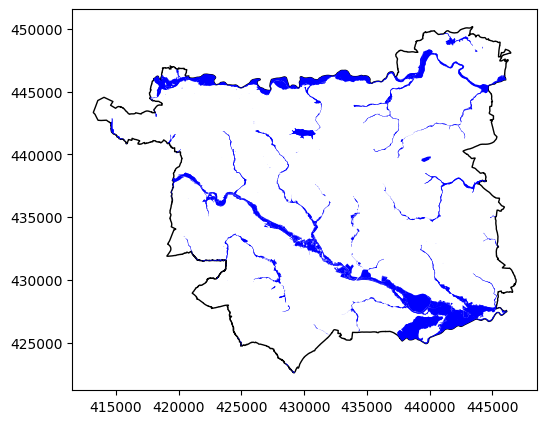

In [30]:
#Subset data to LA
Flooding = Flooding.to_crs(epsg= 27700)
flooding = gpd.clip(Flooding, LA_outline)

#Check
fig , ax = plt.subplots(figsize=(6, 6))

#Plot outline first
LA_outline.plot(
    ax= ax,
    facecolor= 'none',
    edgecolor='black',
    linewidth=1
)

#Plot brown fields
flooding.plot(
    ax=ax,
    color='blue'
)

plt.show()

In [31]:
flooding['entry-date'].value_counts()

entry-date
2023-08-24    4717
Name: count, dtype: int64

In [32]:
flooding['flood-risk-level'].value_counts()

flood-risk-level
2    4548
3     169
Name: count, dtype: int64

In [33]:
flooding['flood-risk-type'].value_counts()

flood-risk-type
Fluvial Models                                   1855
Fluvial Events                                   1644
Fluvial Models and Fluvial Events                 434
Undefined Events                                  297
Fluvial / Undefined Events                        237
Fluvial Models and Undefined Events               138
Fluvial Models and Fluvial / Undefined Events     112
Name: count, dtype: int64

In [34]:
#Convert CRS to 4326 for mapping on dashboard
print(flooding.crs)
flooding = flooding.to_crs(4326)
print(flooding.crs)

EPSG:27700
EPSG:4326


In [35]:
flooding.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 4717 entries, 726168 to 728794
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   dataset              4717 non-null   str           
 1   end-date             4717 non-null   str           
 2   entity               4717 non-null   str           
 3   entry-date           4717 non-null   datetime64[ms]
 4   name                 4717 non-null   str           
 5   organisation-entity  4717 non-null   str           
 6   prefix               4717 non-null   str           
 7   quality              4717 non-null   str           
 8   reference            4717 non-null   str           
 9   start-date           4717 non-null   str           
 10  typology             4717 non-null   str           
 11  flood-risk-level     4717 non-null   str           
 12  flood-risk-type      4717 non-null   str           
 13  geometry             47

In [36]:
#Change the Class to be more explicit for users
flooding['Class']= flooding['flood-risk-level'].replace({
    '2': 'Fluvial - Secondary Flood Potential',
    '3': 'Fluvial - High Flood Potential',
})


In [37]:
flooding['Legend']= flooding['Class'].replace({
    'Fluvial - High Flood Potential': 'Higher flood potential from rivers: the first areas to experience the effects of inland flooding in a river catchment.',
    'Fluvial - Secondary Flood Potential': 'Lower flood potential from rivers: areas affected by secondary flooding in extreme cases as a result of a prolonged flood event.',
})
flooding.head()

,dataset,end-date,entity,entry-date,name,organisation-entity,prefix,quality,reference,start-date,typology,flood-risk-level,flood-risk-type,geometry,Class,Legend
726168,flood-risk-zone,,65764906,2023-08-24,,600009,flood-risk-zone,authoritative,214286/3,,geography,3,Fluvial Models,"POLYGON ((-1.5658 53.70357, -1.5658 53.70357, ...",Fluvial - High Flood Potential,Higher flood potential from rivers: the first ...
451965,flood-risk-zone,,65475273,2023-08-24,,600009,flood-risk-zone,authoritative,475274/2,,geography,2,Fluvial Events,"POLYGON ((-1.56664 53.70419, -1.5666 53.70414,...",Fluvial - Secondary Flood Potential,Lower flood potential from rivers: areas affec...
486056,flood-risk-zone,,65509910,2023-08-24,,600009,flood-risk-zone,authoritative,509911/2,,geography,2,Fluvial Models and Fluvial Events,"POLYGON ((-1.56661 53.7042, -1.56671 53.70428,...",Fluvial - Secondary Flood Potential,Lower flood potential from rivers: areas affec...
469893,flood-risk-zone,,65493571,2023-08-24,,600009,flood-risk-zone,authoritative,493572/2,,geography,2,Fluvial Models,"POLYGON ((-1.56646 53.70468, -1.56651 53.70469...",Fluvial - Secondary Flood Potential,Lower flood potential from rivers: areas affec...
486061,flood-risk-zone,,65509915,2023-08-24,,600009,flood-risk-zone,authoritative,509916/2,,geography,2,Fluvial Models and Fluvial Events,"POLYGON ((-1.56877 53.7054, -1.56864 53.70545,...",Fluvial - Secondary Flood Potential,Lower flood potential from rivers: areas affec...


In [38]:
flooding= flooding[["Class",
                    "Legend",
                    "geometry"]]

In [39]:
#Avoid having overlapping high and secondary flood risk polygons
#needs to be one or the other not both at the same time

priorities= {
    'Fluvial - High Flood Potential': 1,
    'Fluvial - Secondary Flood Potential': 2,
}

flooding['priorities']= flooding['Class'].map(priorities)

results= []

#Highest priority is high flood risk
principal = flooding[flooding['priorities'] == 1]
underlying = flooding[flooding['priorities'] == 2]

#Combine all principal geometries into one
principal_union= principal.geometry.union_all()

#Cut the principal area out of underlying geometries
underlying = underlying.copy()
underlying['geometry']= underlying.geometry.difference(principal_union)

#Remove geometries that have been completely covered
underlying= underlying[~underlying.geometry.is_empty]

#Put them back together
Flooding_corrected= gpd.GeoDataFrame(
    pd.concat([principal, underlying], ignore_index=True),
    crs= flooding.crs
)

In [40]:
#Save Locally
Flooding_corrected.to_file((os.path.join(DATA_DIR, "flooding.gpkg")), driver='GPKG')
#Save in workspace
Flooding_corrected.to_file((os.path.join(workspace_path, "Data", "Processed_Data", "flooding.gpkg")), driver='GPKG')

## 4- Creating PPFI and IMD Layers - HASP + UK Gov

The following PPFI (Priority Places for Food Index) data at the LSOA level is downloaded from [HASP](https://data.hasp.ac.uk/browser/dataset/5276/0). There are 482 LSOAs in Leeds.

In [41]:
#Load file
UK_PPFI = pd.read_csv('../Data/Raw_Data/hasp_ppfi_v2.1.csv')
UK_PPFI.head()

,lsoa21cd,domain_supermarket_proximity,domain_supermarket_accessibility,domain_ecommerce_access,domain_socio_demographic,domain_nonsupermarket_proximity,domain_food_for_families,domain_fuel_poverty,country,country_denominator,combined,pp_dec_domain_supermarket_proximity,pp_dec_domain_supermarket_accessibility,pp_dec_domain_ecommerce_access,pp_dec_domain_socio_demographic,pp_dec_domain_nonsupermarket_proximity,pp_dec_domain_food_for_families,pp_dec_domain_fuel_poverty,pp_dec_combined
0,95AA01S1,480,NaN,NaN,810,518,760,NaN,NI,890,810,6,NaN,NaN,10,6,9,NaN,10
1,95AA01S2,446,NaN,NaN,789,511,793,NaN,NI,890,807,6,NaN,NaN,9,6,9,NaN,10
2,95AA01S3,435,NaN,NaN,688,291,686,NaN,NI,890,549,5,NaN,NaN,8,4,8,NaN,7
3,95AA02W1,714,NaN,NaN,470,661,237,NaN,NI,890,454,9,NaN,NaN,6,8,3,NaN,6
4,95AA03W1,344,NaN,NaN,218,467,614,NaN,NI,890,242,4,NaN,NaN,3,6,7,NaN,3


The following IMD (Index of Multiple Deprivation) data is dowloaded from [UK Gov](https://www.gov.uk/government/statistics/english-indices-of-deprivation-2025).

In [42]:
#Load IMD data for whole of UK
UK_IMD= pd.read_excel('../Data/Raw_Data/File_1_IoD2025_Index_of_Multiple_Deprivation.xlsx', sheet_name='IMD25')
UK_IMD.head()

,LSOA code (2021),LSOA name (2021),Local Authority District code (2024),Local Authority District name (2024),Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived),Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOA
0,E01000001,City of London 001A,E09000001,City of London,26525,8
1,E01000002,City of London 001B,E09000001,City of London,31203,10
2,E01000003,City of London 001C,E09000001,City of London,25913,8
3,E01000005,City of London 001E,E09000001,City of London,14807,5
4,E01000006,Barking and Dagenham 016A,E09000002,Barking and Dagenham,10917,4


There is a need to keep the PPFI and IMD data only for LSOAs within Leeds. To do this, the boundaries of the Leeds LSOAs are sourced from [ONS](https://geoportal.statistics.gov.uk/datasets/ons::lower-layer-super-output-areas-december-2021-boundaries-ew-bsc-v4-2/about).

In [43]:
#Load LSOA boundaries for whole of UK
UK_LSOA= gpd.read_file('../Data/Raw_Data/Lower_layer_Super_Output_Areas_December_2021_Boundaries_EW_BSC_V4_6894679968818356315.geojson')
print(UK_LSOA.crs)
UK_LSOA.head()

EPSG:4326


,FID,LSOA21CD,LSOA21NM,LSOA21NMW,BNG_E,BNG_N,LAT,LONG,GlobalID,geometry
0,1,E01000001,City of London 001A,,532123,181632,51.51817,-0.097150,3478c558-3297-4e2b-979e-e29dd9ff3bf5,"POLYGON ((-0.09474 51.5206, -0.09546 51.51544,..."
1,2,E01000002,City of London 001B,,532480,181715,51.51883,-0.091970,f2072109-b1ae-426c-b166-083cc32f1789,"POLYGON ((-0.0881 51.51941, -0.09546 51.51544,..."
2,3,E01000003,City of London 001C,,532239,182033,51.52174,-0.095330,a9009c33-9b6b-4230-ba62-fc3264806de4,"POLYGON ((-0.09453 51.52205, -0.09274 51.52139..."
3,4,E01000005,City of London 001E,,533581,181283,51.51469,-0.076280,86aee0aa-079f-4f92-8f9d-5773824f4945,"POLYGON ((-0.07589 51.5159, -0.07394 51.51445,..."
4,5,E01000006,Barking and Dagenham 016A,,544994,184274,51.53875,0.089317,c33f1f5b-6b15-47a1-b046-b6a148a9f6d3,"POLYGON ((0.09328 51.53787, 0.09363 51.53767, ..."


<Axes: >

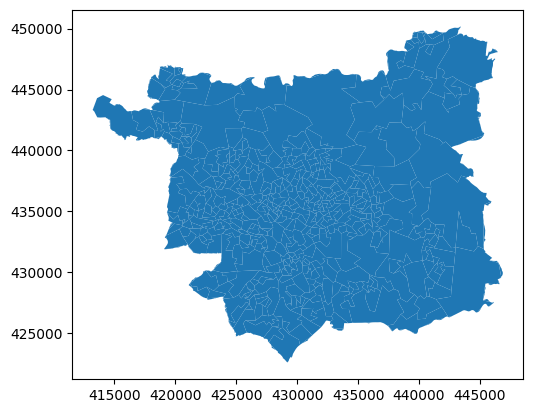

In [44]:
#Clip to only keep LSOA boundaries for Leeds LA
UK_LSOA= UK_LSOA.to_crs(epsg=27700)
Leeds_LSOA = gpd.clip(UK_LSOA, LA_outline)
Leeds_LSOA.plot()

In [45]:
Leeds_LSOA['LSOA21CD'].count()
#Should have 482 LSOAs, but have 539 because LA boundaries dont exactly fit LSOA boundaries

np.int64(539)

The PPFI and IMD data is now merged with the LSOA boundaries:

In [46]:
#Merge and keep the IMD data only for LSOAs in Leeds
Leeds_IMD= Leeds_LSOA.merge(
    UK_IMD,
    left_on= 'LSOA21CD',
    right_on= 'LSOA code (2021)',
    how='left'
)
Leeds_IMD= gpd.GeoDataFrame(Leeds_IMD,
                             geometry= 'geometry',
                             crs= Leeds_LSOA.crs)
Leeds_IMD.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 539 entries, 0 to 538
Data columns (total 16 columns):
 #   Column                                                                            Non-Null Count  Dtype   
---  ------                                                                            --------------  -----   
 0   FID                                                                               539 non-null    int32   
 1   LSOA21CD                                                                          539 non-null    str     
 2   LSOA21NM                                                                          539 non-null    str     
 3   LSOA21NMW                                                                         539 non-null    str     
 4   BNG_E                                                                             539 non-null    int32   
 5   BNG_N                                                                             539 non-null    

In [47]:
#Merge and keep the PFFI data only for LSOAs in Leeds
Leeds_IMD_PPFI= Leeds_IMD.merge(
    UK_PPFI,
    left_on= 'LSOA21CD',
    right_on= 'lsoa21cd',
    how='left'
)
Leeds_IMD_PPFI= gpd.GeoDataFrame(Leeds_IMD_PPFI,
                             geometry= 'geometry',
                             crs= Leeds_IMD.crs)
Leeds_IMD_PPFI.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 539 entries, 0 to 538
Data columns (total 35 columns):
 #   Column                                                                            Non-Null Count  Dtype   
---  ------                                                                            --------------  -----   
 0   FID                                                                               539 non-null    int32   
 1   LSOA21CD                                                                          539 non-null    str     
 2   LSOA21NM                                                                          539 non-null    str     
 3   LSOA21NMW                                                                         539 non-null    str     
 4   BNG_E                                                                             539 non-null    int32   
 5   BNG_N                                                                             539 non-null    

In [48]:
Leeds_IMD_PPFI['LSOA21NM'].unique()

<StringArray>
['Wakefield 013A', 'Wakefield 009D',     'Leeds 103C', 'Wakefield 004B',
 'Wakefield 002F',     'Leeds 103E', 'Wakefield 002A',     'Leeds 103D',
     'Leeds 103A',     'Leeds 103B',
 ...
     'Leeds 001C',     'Leeds 002B',     'Leeds 001A',     'Leeds 001B',
 'Harrogate 016E',     'Leeds 002A', 'Harrogate 016B',     'Leeds 003C',
     'Leeds 001D',     'Leeds 001E']
Length: 539, dtype: str

In [49]:
#Keep only metrics used in dashboard
Leeds_IMD_PPFI= Leeds_IMD_PPFI[['LSOA21CD',
                                'LSOA21NM',
                                
                                'Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOA',
                                
                                'pp_dec_combined', 
                                'pp_dec_domain_supermarket_proximity',
                                'pp_dec_domain_supermarket_accessibility',
                                'pp_dec_domain_socio_demographic',
                                'pp_dec_domain_nonsupermarket_proximity',
                                
                                
                                'geometry']]
Leeds_IMD_PPFI.head()

#Rename
Leeds_IMD_PPFI= Leeds_IMD_PPFI.rename(columns={'Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOA':'IMD_Decile'})

In [50]:
Leeds_IMD_PPFI['pp_dec_domain_supermarket_accessibility'].unique()

array([ 9.,  7.,  8.,  5.,  3.,  6.,  4., 10.,  2.,  1.])

In [51]:
Leeds_IMD_PPFI.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 539 entries, 0 to 538
Data columns (total 9 columns):
 #   Column                                   Non-Null Count  Dtype   
---  ------                                   --------------  -----   
 0   LSOA21CD                                 539 non-null    str     
 1   LSOA21NM                                 539 non-null    str     
 2   IMD_Decile                               539 non-null    int64   
 3   pp_dec_combined                          539 non-null    int64   
 4   pp_dec_domain_supermarket_proximity      539 non-null    int64   
 5   pp_dec_domain_supermarket_accessibility  539 non-null    float64 
 6   pp_dec_domain_socio_demographic          539 non-null    int64   
 7   pp_dec_domain_nonsupermarket_proximity   539 non-null    int64   
 8   geometry                                 539 non-null    geometry
dtypes: float64(1), geometry(1), int64(5), str(2)
memory usage: 38.0 KB


In [52]:
#Convert all of them to integers (currently have a mix of str, float and int)
Leeds_IMD_PPFI['IMD_Decile']= Leeds_IMD_PPFI['IMD_Decile'].astype('Int64')
Leeds_IMD_PPFI['pp_dec_combined']= Leeds_IMD_PPFI['pp_dec_combined'].astype('Int64')
Leeds_IMD_PPFI['pp_dec_domain_supermarket_proximity']= Leeds_IMD_PPFI['pp_dec_domain_supermarket_proximity'].astype('Int64')
Leeds_IMD_PPFI['pp_dec_domain_supermarket_accessibility']= Leeds_IMD_PPFI['pp_dec_domain_supermarket_accessibility'].astype('Int64')
Leeds_IMD_PPFI['pp_dec_domain_socio_demographic']= Leeds_IMD_PPFI['pp_dec_domain_socio_demographic'].astype('Int64')
Leeds_IMD_PPFI['pp_dec_domain_nonsupermarket_proximity']= Leeds_IMD_PPFI['pp_dec_domain_nonsupermarket_proximity'].astype('Int64')

In [53]:
#Save Locally
Leeds_IMD_PPFI.to_file((os.path.join(DATA_DIR, "Leeds_Demo.gpkg")), driver='GPKG')
#Save in workspace
Leeds_IMD_PPFI.to_file((os.path.join(workspace_path, "Data", "Processed_Data", "Leeds_Demo.gpkg")), driver='GPKG')